In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

2026-04-30 11:37:19.322597: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-30 11:37:19.351582: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Train:", X_train.shape)
print("Test:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 323s 2us/step 
Train: (50000, 32, 32, 3)
Test: (10000, 32, 32, 3)


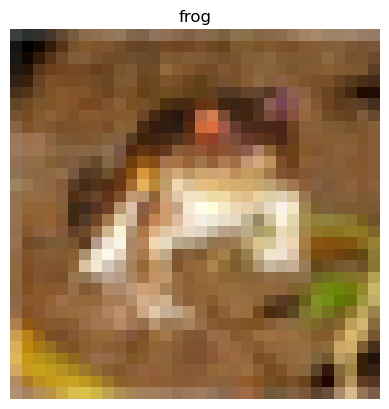

In [3]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.imshow(X_train[0])
plt.title(class_names[y_train[0][0]])
plt.axis('off')
plt.show()

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [5]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

/opt/intel/oneapi/intelpython/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 70ms/step - accuracy: 0.4173 - loss: 1.6304 - val_accuracy: 0.5181 - val_loss: 1.3562
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 72ms/step - accuracy: 0.5640 - loss: 1.2247 - val_accuracy: 0.5249 - val_loss: 1.3457
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 72ms/step - accuracy: 0.6358 - loss: 1.0431 - val_accuracy: 0.6283 - val_loss: 1.0951
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 75ms/step - accuracy: 0.6805 - loss: 0.9203 - val_accuracy: 0.6934 - val_loss: 0.9300
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 82ms/step - accuracy: 0.7108 - loss: 0.8360 - val_accuracy: 0.7131 - val_loss: 0.8488
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - accuracy: 0.7368 - loss: 0.7605 - val_accuracy: 0.7081 - val_loss: 0.8455
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 60s 77ms/step - accuracy: 0.7627 - loss: 0.6881 - val_accuracy: 0.7392 - val_loss: 0.8007
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.7799 - loss: 0.6330 - 

In [8]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.7495 - loss: 0.9783
Accuracy: 0.7494999766349792


313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step


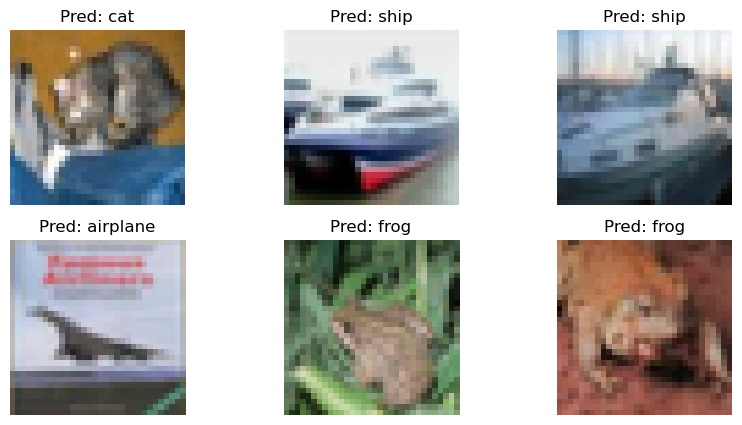

In [9]:
# Class names
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Predict
predictions = model.predict(X_test)

# Show some predictions
plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X_test[i])
    plt.title("Pred: " + class_names[np.argmax(predictions[i])])
    plt.axis('off')

plt.show()